<a href="https://colab.research.google.com/github/saadbinather/Multi-Factor-Stock-Forecasting-FW/blob/main/Baseline%2Bsentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install gnewsclient

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

from collections import OrderedDict
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras import Input
from tensorflow.keras.layers import Bidirectional

from gnewsclient import gnewsclient

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import OrderedDict
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras import Input
from tensorflow.keras.layers import Bidirectional





In [ ]:


companies_dict = OrderedDict({
    'Amazon':'AMZN',
    'Apple':'AAPL',
    'Nike':'NKE',
    'Google':'GOOGL',
    'META':'META'
})

In [ ]:
!pip install gnews

In [ ]:
from datetime import datetime

industry_keywords = {
    'Amazon': [
        # Core financial / stock movers
        'Amazon earnings', 'Amazon quarterly results', 'Amazon revenue',
        'Amazon profit', 'AMZN stock', 'Amazon guidance', 'Amazon EPS',
        'Amazon pre-market', 'Amazon after-hours', 'Amazon target price',

        # AWS (biggest valuation driver)
        'AWS earnings', 'Amazon Web Services revenue', 'AWS growth',

        # Major business events
        'Amazon acquisition', 'Amazon partnership', 'Amazon investment',
        'Amazon expansion', 'Amazon Prime', 'Amazon sales',

        # Workforce / major impact news
        'Amazon layoffs', 'Amazon labor union', 'Amazon strike',

        # Regulatory / legal (major stock movers)
        'Amazon lawsuit', 'Amazon antitrust', 'FTC Amazon', 'Amazon investigation',

        # Leadership (only major ones)
        'Andy Jassy Amazon', 'Jeff Bezos Amazon',

        # Market sentiment
        'Amazon analyst', 'Amazon rating', 'Amazon upgrade', 'Amazon downgrade',
        'Amazon price target', 'Amazon bull', 'Amazon bear'
    ],

    'Apple': [
        # Core financial
        'Apple earnings', 'Apple quarterly results', 'Apple revenue',
        'Apple profit', 'AAPL stock', 'Apple guidance', 'Apple EPS',
        'Apple pre-market', 'Apple after-hours', 'Apple target price',

        # Products (stock movers)
        'Apple iPhone', 'iPhone sales', 'iPhone shipment',
        'Apple MacBook', 'Apple iPad', 'Apple Watch', 'Apple Vision Pro',
        'Apple services revenue', 'App Store revenue',

        # Leadership
        'Tim Cook Apple', 'Apple CEO',

        # Business events
        'Apple product launch', 'Apple event', 'Apple supply chain',
        'Apple China', 'Apple production', 'Apple supplier',

        # Capital allocation
        'Apple dividend', 'Apple buyback', 'Apple stock split',

        # Regulatory/legal
        'Apple lawsuit', 'Apple antitrust', 'DOJ Apple', 'Apple EU',

        # Market sentiment
        'Apple analyst', 'Apple rating', 'Apple upgrade', 'Apple downgrade',
        'AAPL price target', 'Apple bull', 'Apple bear'
    ],

    'Nike': [
        # Core financial
        'Nike earnings', 'Nike quarterly results', 'Nike revenue',
        'Nike profit', 'NKE stock', 'Nike guidance', 'Nike EPS',
        'Nike pre-market', 'Nike after-hours',

        # Sales metrics
        'Nike sales', 'Nike direct sales', 'Nike China sales',
        'Nike North America sales', 'Nike inventory',

        # Leadership
        'Nike CEO', 'Nike executive',

        # Business events
        'Nike product launch', 'Nike sponsorship', 'Nike partnership',
        'Nike collaboration', 'Nike brand',

        # Market position
        'Nike market share', 'Nike competition', 'Nike Adidas',

        # Regulatory/legal
        'Nike lawsuit', 'Nike investigation',

        # Market sentiment
        'Nike analyst', 'Nike rating', 'Nike upgrade', 'Nike downgrade',
        'NKE price target', 'Nike bull', 'Nike bear'
    ],

    'Google': [
        # Core financial
'Alphabet 2022 earnings report', 'Google Q1 2023 financial results',
    'Alphabet revenue growth 2022', 'Google 2023 earnings beat miss',
    'GOOGL stock pre-market reaction 2023', 'Alphabet guidance update 2023',

    # Advertising
    'Google search ad revenue 2022', 'YouTube advertising revenue decline 2023',
    'Alphabet digital ad market share 2023', 'Google Ads policy update 2022',

    # Cloud
    'Google Cloud revenue growth 2022', 'GCP reaches profitability 2023',
    'Google Cloud enterprise deals 2023', 'Google Cloud Next announcements 2023',

    # AI (The major 2022-2023 shift)
    'Google announces Bard AI', 'Google response to ChatGPT 2023',
    'Google Gemini launch 2023', 'Google DeepMind merger 2023',
    'Alphabet AI integration announcement 2023', 'Google AI event 2023',

    # Leadership
    'Sundar Pichai memo to employees 2023', 'Alphabet CEO Sundar Pichai interview 2022',
    'Google executive leadership changes 2023',

    # Regulatory
    'DOJ Google antitrust lawsuit 2023', 'Google EU fine ruling 2022',
    'Google ad tech antitrust 2023', 'Alphabet CMA investigation UK 2022',

    # Business events (Cost cutting and major acquisitions)
    'Google announces 12000 layoffs 2023', 'Alphabet cost cutting measures 2022',
    'Google acquires Mandiant 2022', 'Google office closures 2023',

    # Market sentiment
    'GOOGL stock upgraded downgraded 2023', 'Alphabet price target cut 2022',
    'Wall Street analyst GOOGL rating 2023', 'Morgan Stanley Google note 2023'
],

  'META': [
        # Core financial
        'Meta earnings', 'Facebook revenue', 'Meta quarterly results',
        'Meta revenue', 'META stock', 'FB stock', 'Meta profit',
        'Meta guidance', 'Meta EPS', 'Meta pre-market', 'Meta after-hours',

        # Advertising (Fixed generics to be Meta-specific)
        'Meta advertising revenue', 'Facebook ads', 'Instagram ads',
        'Meta ad pricing', 'Facebook ad impressions', 'Meta CPM',

        # Platforms (Fixed generics)
        'Facebook users', 'Instagram growth', 'WhatsApp business', 'Meta Threads',
        'Instagram Reels engagement', 'Facebook daily active users', 'Meta monthly active users',

        # Leadership & Strategy (Added 2022/23 specific context)
        'Mark Zuckerberg Meta', 'Meta CEO', 'Meta Year of Efficiency',

        # Metaverse & AI (Cost centers & pivots)
        'Meta metaverse', 'Reality Labs', 'Meta VR', 'Meta loss',
        'Meta Generative AI', 'Meta LLaMA', # Crucial for 2023 stock movement

        # Efficiency
        'Meta layoffs', 'Meta cost cutting', 'Meta hiring freeze',

        # Competition & Macro (Fixed generics)
        'Meta vs TikTok', 'Facebook Apple privacy', 'Meta iOS update impact',

        # Regulatory
        'Meta lawsuit', 'FTC Meta', 'Instagram safety hearing', 'Meta fine',

        # Market sentiment
        'Meta analyst', 'META rating', 'Meta upgrade', 'Meta downgrade',
        'Meta price target', 'Meta bull', 'Meta bear'
    ]}

# Date range
start_date = datetime(2022, 1, 1)
end_date = datetime(2023, 1, 15)

# Initialize GNews client
client = gnewsclient.NewsClient(language='english', location='Pakistan', max_results=100)

In [ ]:
pip install GoogleNews

In [ ]:
from gnews import GNews
import pandas as pd

all_news = []

for keyword in industry_keywords['Amazon']:

    google_news = GNews(language='en', country='US', max_results=100)
    google_news.start_date = (2022, 1, 1)
    google_news.end_date   = (2023, 1, 15)

    news = google_news.get_news(keyword)

    for article in news:
        all_news.append({
            "date": article.get("published date"),
            "title": article.get("title"),
            "description": article.get("description")
        })

df_amazon = pd.DataFrame(all_news).drop_duplicates()

df_amazon['date'] = pd.to_datetime(df_amazon['date'], errors='coerce')
df_amazon = df_amazon.dropna(subset=['date'])
df_amazon = df_amazon.sort_values(by='date')

print(df_amazon.head())

                    date                                              title  \
1794 2022-01-03 08:00:00  Amazon must face biometric privacy lawsuit ove...   
1446 2022-01-04 08:00:00  Beauty & Wellness Briefing: Amazon's unauthori...   
1007 2022-01-04 08:00:00  How to Build a Fintech App on AWS Using the Pl...   
1866 2022-01-04 08:00:00  Amazon and Google deploy their armies to thwar...   
424  2022-01-05 08:00:00  Rivian stock plunges after news of Amazon-Stel...   

                                            description  
1794  Amazon must face biometric privacy lawsuit ove...  
1446  Beauty & Wellness Briefing: Amazon's unauthori...  
1007  How to Build a Fintech App on AWS Using the Pl...  
1866  Amazon and Google deploy their armies to thwar...  
424   Rivian stock plunges after news of Amazon-Stel...  


In [ ]:
df_amazon.shape

(2151, 3)

In [ ]:
all_news = []

for keyword in industry_keywords['Apple']:

    google_news = GNews(language='en', country='US', max_results=100)
    google_news.start_date = (2022, 1, 1)
    google_news.end_date   = (2023, 1, 15)

    news = google_news.get_news(keyword)

    for article in news:
        all_news.append({
            "date": article.get("published date"),
            "title": article.get("title"),
            "description": article.get("description")
        })

df_apple = pd.DataFrame(all_news).drop_duplicates()

df_apple['date'] = pd.to_datetime(df_apple['date'], errors='coerce')
df_apple = df_apple.dropna(subset=['date'])
df_apple = df_apple.sort_values(by='date')

print(df_apple.head())

                    date                                              title  \
1638 2022-01-01 08:00:00  What Do You Want to See From Apple in 2022? - ...   
2507 2022-01-01 08:00:00  CCI orders investigation into Apple's business...   
1678 2022-01-01 08:00:00  Major Apple Products That May Arrive in 2022 -...   
621  2022-01-01 08:41:23  TINC N.V.: Target Price Consensus and Analysts...   
924  2022-01-02 08:00:00  How Apple trade-in turned my broken MacBook Pr...   

                                            description  
1638  What Do You Want to See From Apple in 2022?  M...  
2507  CCI orders investigation into Apple's business...  
1678  Major Apple Products That May Arrive in 2022  ...  
621   TINC N.V.: Target Price Consensus and Analysts...  
924   How Apple trade-in turned my broken MacBook Pr...  


In [ ]:
all_news = []

for keyword in industry_keywords['Nike']:

    google_news = GNews(language='en', country='US', max_results=100)
    google_news.start_date = (2022, 1, 1)
    google_news.end_date   = (2023, 1, 15)

    news = google_news.get_news(keyword)

    for article in news:
        all_news.append({
            "date": article.get("published date"),
            "title": article.get("title"),
            "description": article.get("description")
        })

df_nike = pd.DataFrame(all_news).drop_duplicates()

df_nike['date'] = pd.to_datetime(df_nike['date'], errors='coerce')
df_nike = df_nike.dropna(subset=['date'])
df_nike = df_nike.sort_values(by='date')

print(df_nike.head())

                    date                                              title  \
121  2022-01-03 08:00:00  Are Nike’s Member Days loyalty’s future? - Ret...   
285  2022-01-03 08:00:00  Guggenheim names Nike its best idea for 2022, ...   
885  2022-01-05 08:00:00  Nico Harrison on the Mavs' general manager job...   
1440 2022-01-05 08:00:00  Chinese sportswear company Anta gains on Nike,...   
1395 2022-01-05 08:00:00  Lawyer Reveals Little-Known Hack To Get Brand ...   

                                            description  
121   Are Nike’s Member Days loyalty’s future?  Reta...  
285   Guggenheim names Nike its best idea for 2022, ...  
885   Nico Harrison on the Mavs' general manager job...  
1440  Chinese sportswear company Anta gains on Nike,...  
1395  Lawyer Reveals Little-Known Hack To Get Brand ...  


In [ ]:
all_news = []

for keyword in industry_keywords['Google']:

    google_news = GNews(language='en', country='US', max_results=100)
    google_news.start_date = (2022, 1, 1)
    google_news.end_date   = (2023, 1, 15)

    news = google_news.get_news(keyword)

    for article in news:
        all_news.append({
            "date": article.get("published date"),
            "title": article.get("title"),
            "description": article.get("description")
        })

df_google = pd.DataFrame(all_news).drop_duplicates()

df_google['date'] = pd.to_datetime(df_google['date'], errors='coerce')
df_google = df_google.dropna(subset=['date'])
df_google = df_google.sort_values(by='date')

print(df_google.head())

                   date                                              title  \
165 2022-01-04 08:00:00  Investor Michael Seibel Explains Google’s Sear...   
312 2022-01-04 08:00:00  Google removes YouTube ads featuring interroga...   
764 2022-01-05 08:00:00  Google, Facebook face big privacy fines in Fra...   
950 2022-01-05 08:00:00  Amazon was the worst-performing FAANG stock of...   
786 2022-01-06 08:00:00  France fines Google and Facebook €210m over us...   

                                           description  
165  Investor Michael Seibel Explains Google’s Sear...  
312  Google removes YouTube ads featuring interroga...  
764  Google, Facebook face big privacy fines in Fra...  
950  Amazon was the worst-performing FAANG stock of...  
786  France fines Google and Facebook €210m over us...  


In [ ]:
all_news = []

for keyword in industry_keywords['META']:

    google_news = GNews(language='en', country='US', max_results=100)
    google_news.start_date = (2022, 1, 1)
    google_news.end_date   = (2023, 1, 15)

    news = google_news.get_news(keyword)

    for article in news:
        all_news.append({
            "date": article.get("published date"),
            "title": article.get("title"),
            "description": article.get("description")
        })

df_meta = pd.DataFrame(all_news).drop_duplicates()

df_meta['date'] = pd.to_datetime(df_meta['date'], errors='coerce')
df_meta = df_meta.dropna(subset=['date'])
df_meta = df_meta.sort_values(by='date')

print(df_meta.head())

                    date                                              title  \
3079 2022-01-03 06:17:27  Meta Business Systems Analyst Salaries in New ...   
1676 2022-01-03 08:00:00  Decentraland Holds First-Mover Advantage in Ba...   
701  2022-01-03 08:00:00          MAMAA stocks outlook for 2022 - Dr Wealth   
1963 2022-01-04 08:00:00            Money in the Metaverse - The New Yorker   
3313 2022-01-04 08:00:00  Gender, Socioeconomic Status, Cultural Differe...   

                                            description  
3079  Meta Business Systems Analyst Salaries in New ...  
1676  Decentraland Holds First-Mover Advantage in Ba...  
701            MAMAA stocks outlook for 2022  Dr Wealth  
1963             Money in the Metaverse  The New Yorker  
3313  Gender, Socioeconomic Status, Cultural Differe...  


In [ ]:
df_meta.head()

,date,title,description
3079,2022-01-03 06:17:27,Meta Business Systems Analyst Salaries in New ...,Meta Business Systems Analyst Salaries in New ...
1676,2022-01-03 08:00:00,Decentraland Holds First-Mover Advantage in Ba...,Decentraland Holds First-Mover Advantage in Ba...
701,2022-01-03 08:00:00,MAMAA stocks outlook for 2022 - Dr Wealth,MAMAA stocks outlook for 2022 Dr Wealth
1963,2022-01-04 08:00:00,Money in the Metaverse - The New Yorker,Money in the Metaverse The New Yorker
3313,2022-01-04 08:00:00,"Gender, Socioeconomic Status, Cultural Differe...","Gender, Socioeconomic Status, Cultural Differe..."


In [ ]:
!pip install transformers torch

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch


model_name = "ProsusAI/finbert"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

labels = ['negative', 'neutral', 'positive']

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
def get_finbert_sentiment(text):

    if pd.isna(text):
        return 0

    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)

    outputs = model(**inputs)
    probs = torch.nn.functional.softmax(outputs.logits, dim=1)

    sentiment = torch.argmax(probs).item()
    label = labels[sentiment]

    if label == 'positive':
        return 1
    elif label == 'negative':
        return -1
    else:
        return 0

In [ ]:
df_amazon['text'] = df_amazon['title'].fillna('') + " " + df_amazon['description'].fillna('')
df_amazon['sentiment'] = df_amazon['text'].apply(get_finbert_sentiment)


df_amazon['date_only'] = df_amazon['date'].dt.date

daily_amazon = df_amazon.groupby('date_only').agg({
    'sentiment': 'mean',
    'title': 'count'
}).rename(columns={'title': 'news_count'}).reset_index()


In [ ]:
df_apple['text'] = df_apple['title'].fillna('') + " " + df_apple['description'].fillna('')
df_apple['sentiment'] = df_apple['text'].apply(get_finbert_sentiment)


df_apple['date_only'] = df_apple['date'].dt.date
daily_apple = df_apple.groupby('date_only').agg({
    'sentiment': 'mean',
    'title': 'count'
}).rename(columns={'title': 'news_count'}).reset_index()

In [ ]:


df_nike['text'] = df_nike['title'].fillna('') + " " + df_nike['description'].fillna('')
df_nike['sentiment'] = df_nike['text'].apply(get_finbert_sentiment)


df_nike['date_only'] = df_nike['date'].dt.date
daily_nike = df_nike.groupby('date_only').agg({
    'sentiment': 'mean',
    'title': 'count'
}).rename(columns={'title': 'news_count'}).reset_index()





In [ ]:

df_google['text'] = df_google['title'].fillna('') + " " + df_google['description'].fillna('')
df_google['sentiment'] = df_google['text'].apply(get_finbert_sentiment)



df_google['date_only'] = df_google['date'].dt.date
daily_google = df_google.groupby('date_only').agg({
    'sentiment': 'mean',
    'title': 'count'
}).rename(columns={'title': 'news_count'}).reset_index()



In [ ]:
df_meta['text'] = df_meta['title'] + " " + df_meta['description']
df_meta['sentiment'] = df_meta['text'].apply(get_finbert_sentiment)



df_meta['date_only'] = df_meta['date'].dt.date
daily_meta = df_meta.groupby('date_only').agg({
    'sentiment': 'mean',
    'title': 'count'
}).rename(columns={'title': 'news_count'}).reset_index()

In [ ]:
# Yeh code check karega ke kahan text bilkul empty hai ya sirf spaces hain
problematic_rows = df_meta[df_meta['text'].str.strip() == '']

# Unko display karein
display(problematic_rows.head())

,date,title,description,text,sentiment,date_only


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

start = "2022-01-01"
end = "2023-01-15"

print("="*50)
print("APPLE (AAPL) - With Rolling Mean")
print("="*50)

# Download Apple stock data
aapl_stock = yf.download("AAPL", start=start, end=end)

# Flatten MultiIndex columns
aapl_stock.columns = aapl_stock.columns.get_level_values(0)

# Reset index and create date column
aapl_stock = aapl_stock.reset_index()
aapl_stock['date_only'] = aapl_stock['Date'].dt.date

# Merge with sentiment data
df_apple_final = pd.merge(
    aapl_stock,
    daily_apple[['date_only', 'sentiment']],
    on='date_only',
    how='left'
)

# Sort by date
df_apple_final = df_apple_final.sort_values('Date')

# Fill NaN with rolling mean (30-day window)
df_apple_final['sentiment'] = df_apple_final['sentiment'].fillna(   df_apple_final['sentiment'].rolling(30, min_periods=1).mean())
#df_apple_final['sentiment'] = df_apple_final['sentiment'].fillna(0)

# Forward fill any remaining NaN at the beginning
df_apple_final['sentiment'] = df_apple_final['sentiment'].fillna(method='ffill').fillna(method='bfill')

# Drop date_only column
df_apple_final = df_apple_final.drop(columns=['date_only'])

# Rename to df_apple
df_apple = df_apple_final

# Display results
print(f"\n📊 Apple Statistics:")
print(f"Total rows: {len(df_apple)}")
print(f"Date range: {df_apple['Date'].min()} to {df_apple['Date'].max()}")
print(f"Sentiment - Mean: {df_apple['sentiment'].mean():.4f}")
print(f"Sentiment - Std: {df_apple['sentiment'].std():.4f}")
print(f"Sentiment - Min: {df_apple['sentiment'].min():.4f}")
print(f"Sentiment - Max: {df_apple['sentiment'].max():.4f}")

print("\n📋 First 5 rows:")
df_apple.head()

APPLE (AAPL) - With Rolling Mean


/tmp/ipykernel_5375/4284161709.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  aapl_stock = yf.download("AAPL", start=start, end=end)
[*********************100%***********************]  1 of 1 completed


📊 Apple Statistics:
Total rows: 260
Date range: 2022-01-03 00:00:00 to 2023-01-13 00:00:00
Sentiment - Mean: 0.6776
Sentiment - Std: 0.2791
Sentiment - Min: -1.0000
Sentiment - Max: 1.0000

📋 First 5 rows:



/tmp/ipykernel_5375/4284161709.py:38: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_apple_final['sentiment'] = df_apple_final['sentiment'].fillna(method='ffill').fillna(method='bfill')


,Date,Close,High,Low,Open,Volume,sentiment
0,2022-01-03,178.103683,178.955022,173.895982,174.013402,104487900,0.454545
1,2022-01-04,175.843231,179.013699,175.275678,178.710355,99310400,0.333333
2,2022-01-05,171.165833,176.303156,170.891843,175.755177,94537600,0.600000
3,2022-01-06,168.308517,171.537695,167.956243,168.993491,96904000,1.000000
4,2022-01-07,168.474884,170.402605,167.359351,169.179433,86709100,0.857143


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

start = "2022-01-01"
end = "2023-01-15"

print("="*50)
print("AMAZON (AMZN) - With Rolling Mean")
print("="*50)

# Download Amazon stock data
amzn_stock = yf.download("AMZN", start=start, end=end)

# Flatten MultiIndex columns
amzn_stock.columns = amzn_stock.columns.get_level_values(0)

# Reset index and create date column
amzn_stock = amzn_stock.reset_index()
amzn_stock['date_only'] = amzn_stock['Date'].dt.date

# Merge with sentiment data
df_amazon_final = pd.merge(
    amzn_stock,
    daily_amazon[['date_only', 'sentiment']],
    on='date_only',
    how='left'
)

# Sort by date
df_amazon_final = df_amazon_final.sort_values('Date')

# Fill NaN with rolling mean (30-day window)
df_amazon_final['sentiment'] = df_amazon_final['sentiment'].fillna(   df_amazon_final['sentiment'].rolling(30, min_periods=1).mean())
#df_amazon_final['sentiment'] = df_amazon_final['sentiment'].fillna(0)


# Forward fill any remaining NaN at the beginning
df_amazon_final['sentiment'] = df_amazon_final['sentiment'].fillna(method='ffill').fillna(method='bfill')

# Drop date_only column
df_amazon_final = df_amazon_final.drop(columns=['date_only'])

# Rename to df_amazon
df_amazon = df_amazon_final

# Display results
print(f"\n📊 Amazon Statistics:")
print(f"Total rows: {len(df_amazon)}")
print(f"Date range: {df_amazon['Date'].min()} to {df_amazon['Date'].max()}")
print(f"Sentiment - Mean: {df_amazon['sentiment'].mean():.4f}")
print(f"Sentiment - Std: {df_amazon['sentiment'].std():.4f}")
print(f"Sentiment - Min: {df_amazon['sentiment'].min():.4f}")
print(f"Sentiment - Max: {df_amazon['sentiment'].max():.4f}")

print("\n📋 First 5 rows:")
df_amazon.head()

/tmp/ipykernel_5375/345624804.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  amzn_stock = yf.download("AMZN", start=start, end=end)
[*********************100%***********************]  1 of 1 completed

AMAZON (AMZN) - With Rolling Mean

📊 Amazon Statistics:
Total rows: 260
Date range: 2022-01-03 00:00:00 to 2023-01-13 00:00:00
Sentiment - Mean: 0.6550
Sentiment - Std: 0.3123
Sentiment - Min: -1.0000
Sentiment - Max: 1.0000

📋 First 5 rows:



/tmp/ipykernel_5375/345624804.py:39: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_amazon_final['sentiment'] = df_amazon_final['sentiment'].fillna(method='ffill').fillna(method='bfill')


,Date,Close,High,Low,Open,Volume,sentiment
0,2022-01-03,170.404495,170.703506,166.160507,167.550003,63520000,1.000000
1,2022-01-04,167.522003,171.399994,166.349503,170.438004,70726000,0.666667
2,2022-01-05,164.356995,167.126495,164.356995,166.882996,64302000,0.333333
3,2022-01-06,163.253998,164.800003,161.936996,163.450500,51958000,0.666667
4,2022-01-07,162.554001,165.243500,162.031006,163.839005,46606000,0.500000


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

start = "2022-01-01"
end = "2023-01-15"

print("="*50)
print("NIKE (NKE) - With Rolling Mean")
print("="*50)

# Download Nike stock data
nke_stock = yf.download("NKE", start=start, end=end)

# Flatten MultiIndex columns
nke_stock.columns = nke_stock.columns.get_level_values(0)

# Reset index and create date column
nke_stock = nke_stock.reset_index()
nke_stock['date_only'] = nke_stock['Date'].dt.date

# Merge with sentiment data
df_nike_final = pd.merge(
    nke_stock,
    daily_nike[['date_only', 'sentiment']],
    on='date_only',
    how='left'
)

# Sort by date
df_nike_final = df_nike_final.sort_values('Date')

# Fill NaN with rolling mean (30-day window)
df_nike_final['sentiment'] = df_nike_final['sentiment'].fillna(df_nike_final['sentiment'].rolling(30, min_periods=1).mean())

#df_nike_final['sentiment'] = df_nike_final['sentiment'].fillna(0)

# Forward fill any remaining NaN at the beginning
df_nike_final['sentiment'] = df_nike_final['sentiment'].fillna(method='ffill').fillna(method='bfill')

# Drop date_only column
df_nike_final = df_nike_final.drop(columns=['date_only'])

# Rename to df_nike
df_nike = df_nike_final

# Display results
print(f"\n📊 Nike Statistics:")
print(f"Total rows: {len(df_nike)}")
print(f"Date range: {df_nike['Date'].min()} to {df_nike['Date'].max()}")
print(f"Sentiment - Mean: {df_nike['sentiment'].mean():.4f}")
print(f"Sentiment - Std: {df_nike['sentiment'].std():.4f}")
print(f"Sentiment - Min: {df_nike['sentiment'].min():.4f}")
print(f"Sentiment - Max: {df_nike['sentiment'].max():.4f}")

print("\n📋 First 5 rows:")
df_nike.head()

NIKE (NKE) - With Rolling Mean


/tmp/ipykernel_5375/2802049014.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nke_stock = yf.download("NKE", start=start, end=end)
[*********************100%***********************]  1 of 1 completed


📊 Nike Statistics:
Total rows: 260
Date range: 2022-01-03 00:00:00 to 2023-01-13 00:00:00
Sentiment - Mean: 0.7586
Sentiment - Std: 0.3282
Sentiment - Min: -1.0000
Sentiment - Max: 1.0000

📋 First 5 rows:



/tmp/ipykernel_5375/2802049014.py:39: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_nike_final['sentiment'] = df_nike_final['sentiment'].fillna(method='ffill').fillna(method='bfill')


,Date,Close,High,Low,Open,Volume,sentiment
0,2022-01-03,153.479950,156.499783,152.212367,156.145601,5670500,1.000000
1,2022-01-04,155.083130,155.819440,153.787587,154.607792,6064200,1.000000
2,2022-01-05,151.224411,155.660943,151.084610,155.176290,5021000,0.200000
3,2022-01-06,150.096649,152.100556,148.251202,151.075300,4144600,0.571429
4,2022-01-07,146.303192,150.189820,146.200667,149.844968,5108000,0.590476


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

start = "2022-01-01"
end = "2023-01-15"

print("="*50)
print("GOOGLE (GOOGL) - With Rolling Mean")
print("="*50)

# Download Google stock data
googl_stock = yf.download("GOOGL", start=start, end=end)

# Flatten MultiIndex columns
googl_stock.columns = googl_stock.columns.get_level_values(0)

# Reset index and create date column
googl_stock = googl_stock.reset_index()
googl_stock['date_only'] = googl_stock['Date'].dt.date

# Merge with sentiment data
df_google_final = pd.merge(
    googl_stock,
    daily_google[['date_only', 'sentiment']],
    on='date_only',
    how='left'
)

# Sort by date
df_google_final = df_google_final.sort_values('Date')

# Fill NaN with rolling mean (30-day window)
df_google_final['sentiment'] = df_google_final['sentiment'].fillna(df_google_final['sentiment'].rolling(30, min_periods=1).mean())

#df_google_final['sentiment'] = df_google_final['sentiment'].fillna(0)

# Forward fill any remaining NaN at the beginning
df_google_final['sentiment'] = df_google_final['sentiment'].fillna(method='ffill').fillna(method='bfill')

# Drop date_only column
df_google_final = df_google_final.drop(columns=['date_only'])

# Rename to df_google
df_google = df_google_final

# Display results
print(f"\n📊 Google Statistics:")
print(f"Total rows: {len(df_google)}")
print(f"Date range: {df_google['Date'].min()} to {df_google['Date'].max()}")
print(f"Sentiment - Mean: {df_google['sentiment'].mean():.4f}")
print(f"Sentiment - Std: {df_google['sentiment'].std():.4f}")
print(f"Sentiment - Min: {df_google['sentiment'].min():.4f}")
print(f"Sentiment - Max: {df_google['sentiment'].max():.4f}")

print("\n📋 First 5 rows:")
df_google.head()

/tmp/ipykernel_5375/840952062.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  googl_stock = yf.download("GOOGL", start=start, end=end)
[*********************100%***********************]  1 of 1 completed

GOOGLE (GOOGL) - With Rolling Mean

📊 Google Statistics:
Total rows: 260
Date range: 2022-01-03 00:00:00 to 2023-01-13 00:00:00
Sentiment - Mean: 0.6956
Sentiment - Std: 0.3438
Sentiment - Min: -1.0000
Sentiment - Max: 1.0000

📋 First 5 rows:



/tmp/ipykernel_5375/840952062.py:39: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_google_final['sentiment'] = df_google_final['sentiment'].fillna(method='ffill').fillna(method='bfill')


,Date,Close,High,Low,Open,Volume,sentiment
0,2022-01-03,143.802979,144.655430,142.534955,143.865950,28646000,0.000000
1,2022-01-04,143.215820,145.284220,142.538420,144.204142,28400000,0.000000
2,2022-01-05,136.645630,143.315011,136.559353,143.236164,54618000,0.000000
3,2022-01-06,136.618347,138.792880,135.439098,135.875494,37348000,0.333333
4,2022-01-07,135.893829,137.313598,134.653577,137.013073,29760000,0.000000


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

start = "2022-01-01"
end = "2023-01-15"

print("="*50)
print("META (META) - With Rolling Mean")
print("="*50)

# Download Meta stock data
meta_stock = yf.download("META", start=start, end=end)

# Flatten MultiIndex columns
meta_stock.columns = meta_stock.columns.get_level_values(0)

# Reset index and create date column
meta_stock = meta_stock.reset_index()
meta_stock['date_only'] = meta_stock['Date'].dt.date

# Merge with sentiment data
df_meta_final = pd.merge(
    meta_stock,
    daily_meta[['date_only', 'sentiment']],
    on='date_only',
    how='left'
)

# Sort by date
df_meta_final = df_meta_final.sort_values('Date')

# Fill NaN with rolling mean (30-day window)
df_meta_final['sentiment'] = df_meta_final['sentiment'].fillna(df_meta_final['sentiment'].rolling(30, min_periods=1).mean())


#df_meta_final['sentiment'] = df_meta_final['sentiment'].fillna(0)

# Forward fill any remaining NaN at the beginning
df_meta_final['sentiment'] = df_meta_final['sentiment'].fillna(method='ffill').fillna(method='bfill')

# Drop date_only column
df_meta_final = df_meta_final.drop(columns=['date_only'])

# Rename to df_meta
df_meta = df_meta_final

# Display results
print(f"\n📊 Meta Statistics:")
print(f"Total rows: {len(df_meta)}")
print(f"Date range: {df_meta['Date'].min()} to {df_meta['Date'].max()}")
print(f"Sentiment - Mean: {df_meta['sentiment'].mean():.4f}")
print(f"Sentiment - Std: {df_meta['sentiment'].std():.4f}")
print(f"Sentiment - Min: {df_meta['sentiment'].min():.4f}")
print(f"Sentiment - Max: {df_meta['sentiment'].max():.4f}")

print("\n📋 First 5 rows:")
df_meta.head()

/tmp/ipykernel_5375/3228014488.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  meta_stock = yf.download("META", start=start, end=end)


META (META) - With Rolling Mean


[*********************100%***********************]  1 of 1 completed


📊 Meta Statistics:
Total rows: 260
Date range: 2022-01-03 00:00:00 to 2023-01-13 00:00:00
Sentiment - Mean: 0.7239
Sentiment - Std: 0.2896
Sentiment - Min: -1.0000
Sentiment - Max: 1.0000

📋 First 5 rows:



/tmp/ipykernel_5375/3228014488.py:40: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_meta_final['sentiment'] = df_meta_final['sentiment'].fillna(method='ffill').fillna(method='bfill')


,Date,Close,High,Low,Open,Volume,sentiment
0,2022-01-03,336.191589,338.713948,334.850948,335.953234,14537900,0.666667
1,2022-01-04,334.195557,340.710049,329.567879,337.591846,15998000,1.000000
2,2022-01-05,321.921234,333.430830,321.593506,330.709817,20564500,1.000000
3,2022-01-06,330.153748,336.817223,320.481323,320.580635,27962800,0.833333
4,2022-01-07,329.488403,334.662253,326.598586,330.431795,14722000,0.500000


In [ ]:
company_dfs = {
    "Amazon": df_amazon,
    "Apple": df_apple,
    "Nike": df_nike,
    "Google": df_google,
    "Meta": df_meta
}

def create_sequences_multivariate(data, seq_length):

    X = []
    y = []

    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, :])

        y.append(data[i, 3])  # Only predict Close price

    return np.array(X), np.array(y)

In [ ]:
results = []
plot_data = {}

# Map company name to dataframe
company_dfs = {
    "Amazon": df_amazon,
    "Apple": df_apple,
    "Google": df_google,
    "Meta": df_meta,
    "Nike": df_nike
}

for company_name, df in company_dfs.items():

    # Set Date as index
    df = df.copy()
    df.set_index("Date", inplace=True)

    # Use stock features + sentiment
    df = df[['Open', 'High', 'Low', 'Close', 'Volume', 'sentiment']]
    df.dropna(inplace=True)

    # Scale
    scaler = MinMaxScaler(feature_range=(0,1))
    scaled_data = scaler.fit_transform(df)

    seq_length = 30
    X, y = create_sequences_multivariate(scaled_data, seq_length)

    # Split date
    split_date = "2022-12-01"
    split_index = df.index.get_loc(split_date)
    split_index = split_index - seq_length

    X_train = X[:split_index]
    y_train = y[:split_index]

    X_test = X[split_index:]
    y_test = y[split_index:]

    test_dates = df.index[seq_length + split_index:]

    # LSTM Model
    model = Sequential([
        Input(shape=(X_train.shape[1], X_train.shape[2])),  # (30, 6)
        LSTM(50, return_sequences=True),
        Dropout(0.2),
        LSTM(50),
        Dropout(0.2),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=15, batch_size=32, verbose=0)

    predictions = model.predict(X_test, verbose=0)

    # Reconstruct full feature space for inverse scaling
    predictions_full = np.zeros((len(predictions), scaled_data.shape[1]))
    last_sequences = X_test[:, -1, :]
    predictions_full[:, :] = last_sequences
    predictions_full[:, 3] = predictions.flatten()  # Close index

    predictions_actual = scaler.inverse_transform(predictions_full)
    predictions_close = predictions_actual[:, 3].reshape(-1, 1)

    # True values inverse transform
    y_test_full = np.zeros((len(y_test), scaled_data.shape[1]))
    y_test_full[:, :] = last_sequences
    y_test_full[:, 3] = y_test.flatten()
    y_test_actual_full = scaler.inverse_transform(y_test_full)
    y_test_actual = y_test_actual_full[:, 3].reshape(-1, 1)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test_actual, predictions_close))
    mae = mean_absolute_error(y_test_actual, predictions_close)

    results.append({
        "Company": company_name,
        "RMSE": round(rmse, 2),
        "MAE": round(mae, 2)
    })

    plot_data[company_name] = (test_dates, y_test_actual, predictions_close)


In [ ]:
# Convert results to DataFrame
results_df = pd.DataFrame(results)
print(results_df)



  Company  RMSE   MAE
0  Amazon  5.42  4.92
1   Apple  6.53  5.55
2  Google  3.48  2.98
3    Meta  8.81  7.52
4    Nike  6.92  6.35


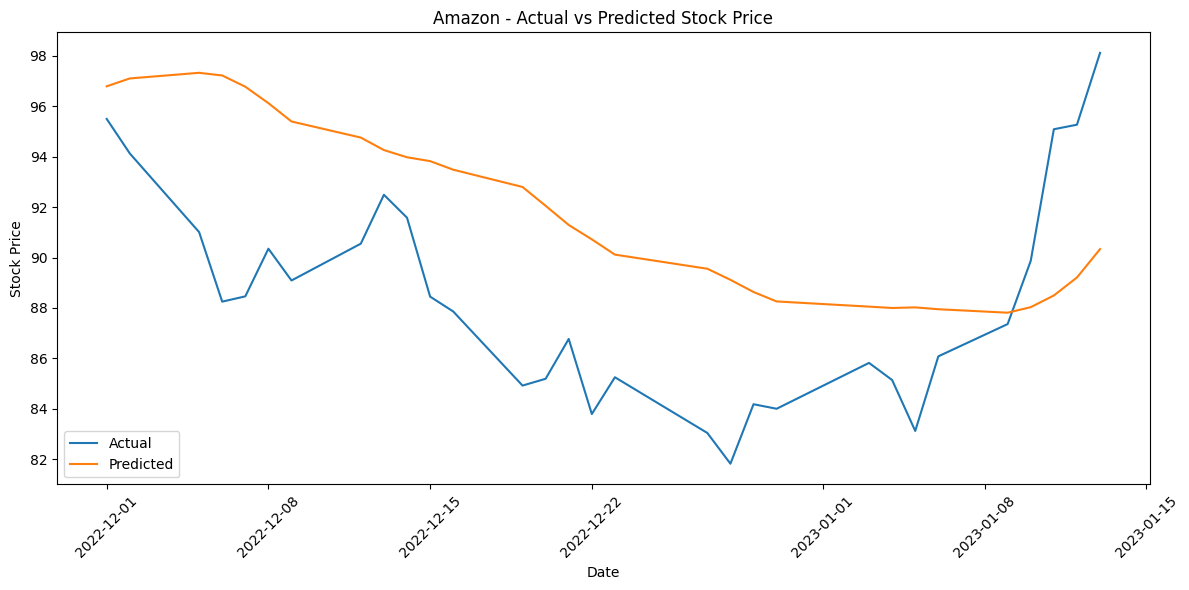

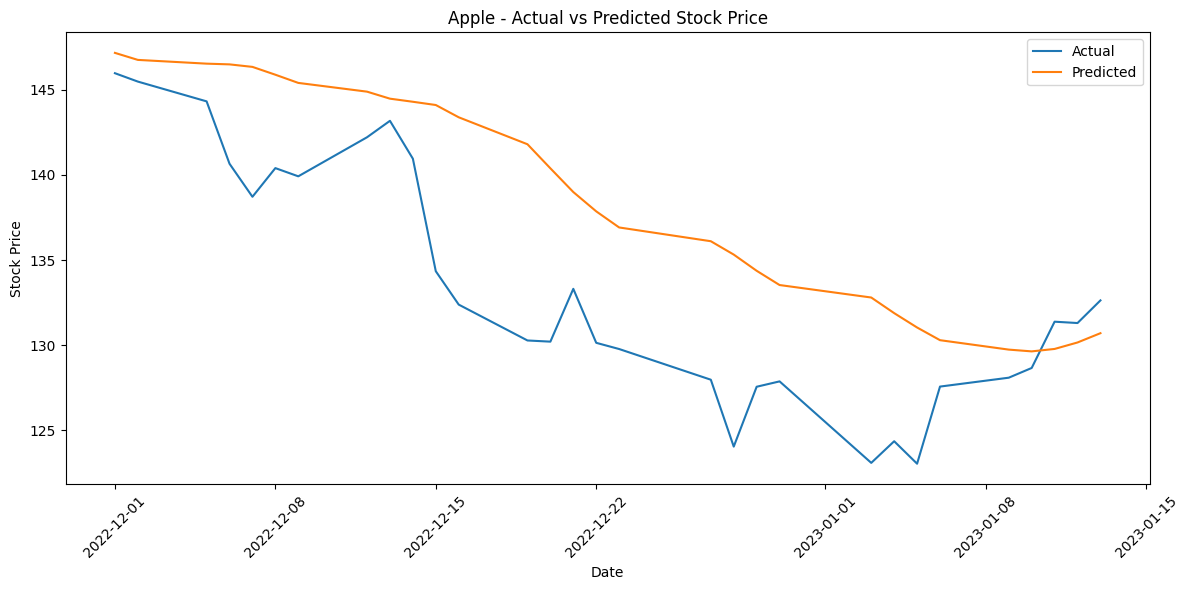

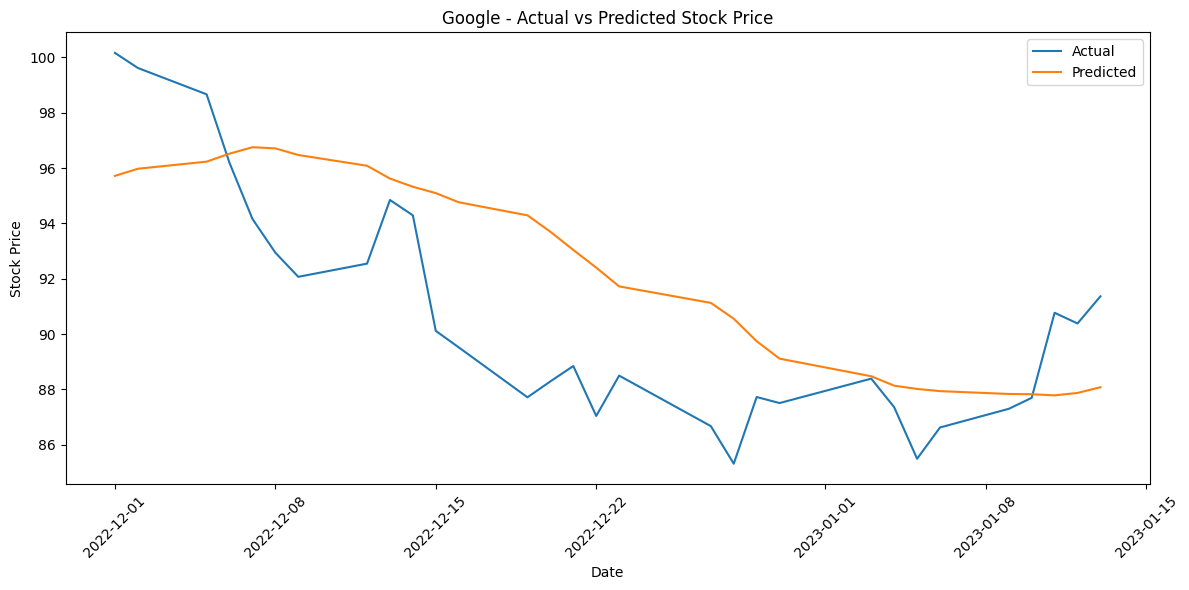

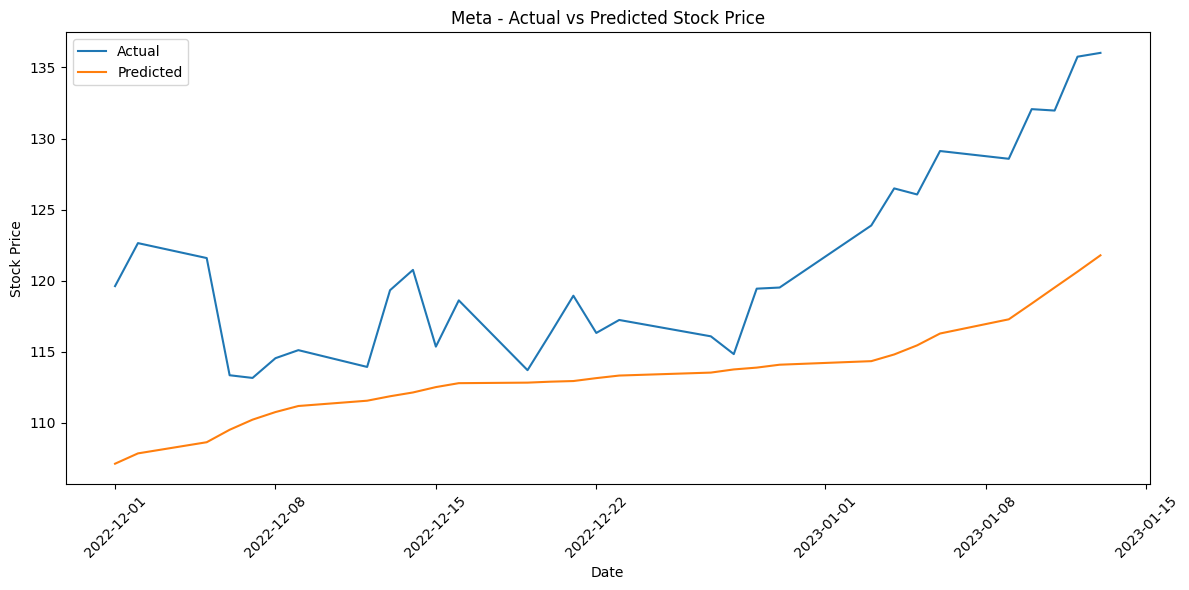

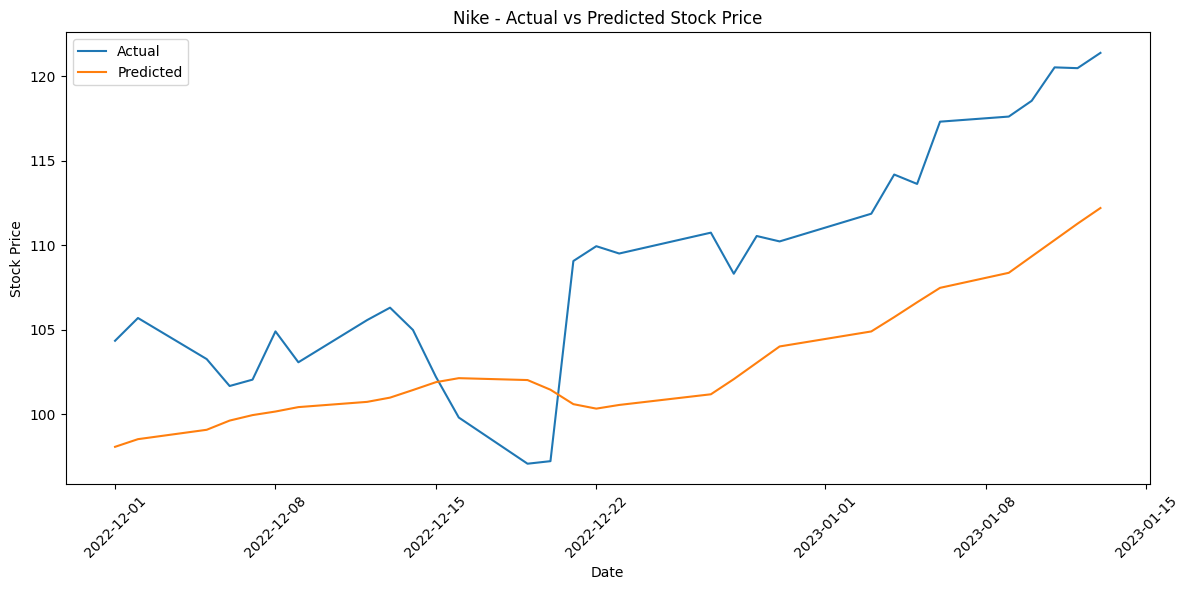

In [ ]:

for company_name in plot_data:

    dates, actual, predicted = plot_data[company_name]

    plt.figure(figsize=(12,6))
    plt.plot(dates, actual, label="Actual")
    plt.plot(dates, predicted, label="Predicted")

    plt.title(f"{company_name} - Actual vs Predicted Stock Price")
    plt.xlabel("Date")
    plt.ylabel("Stock Price")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

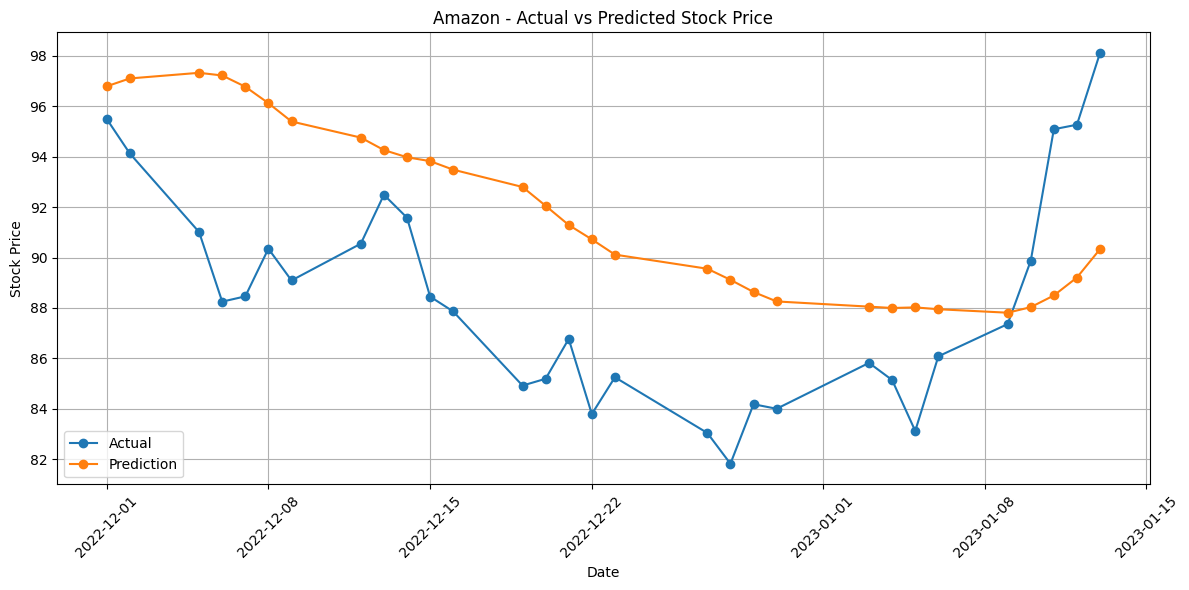

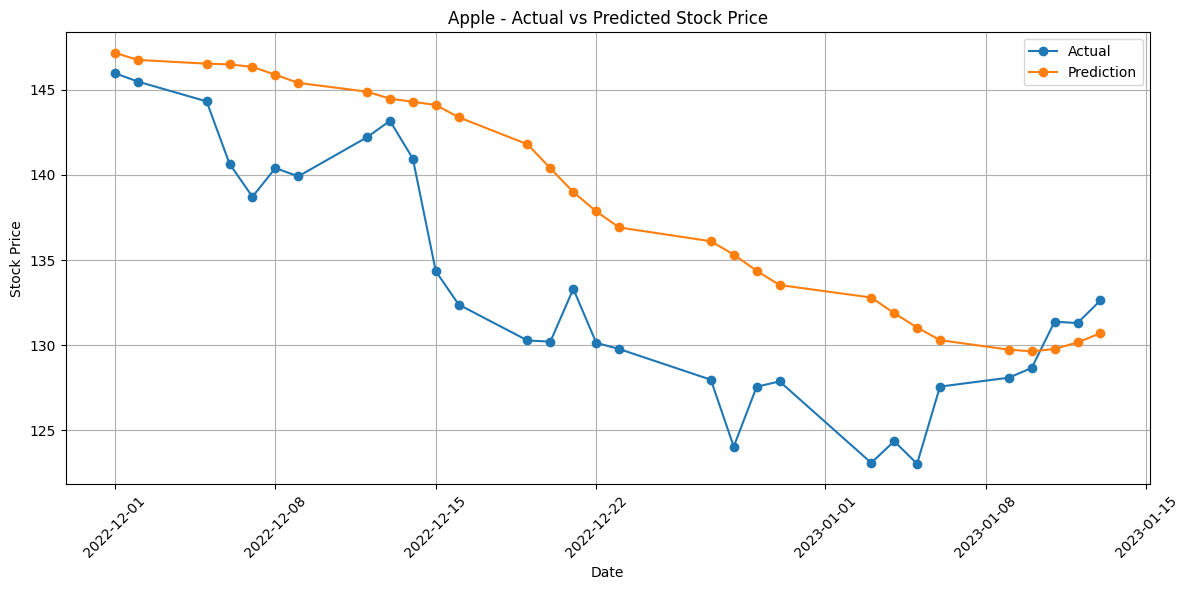

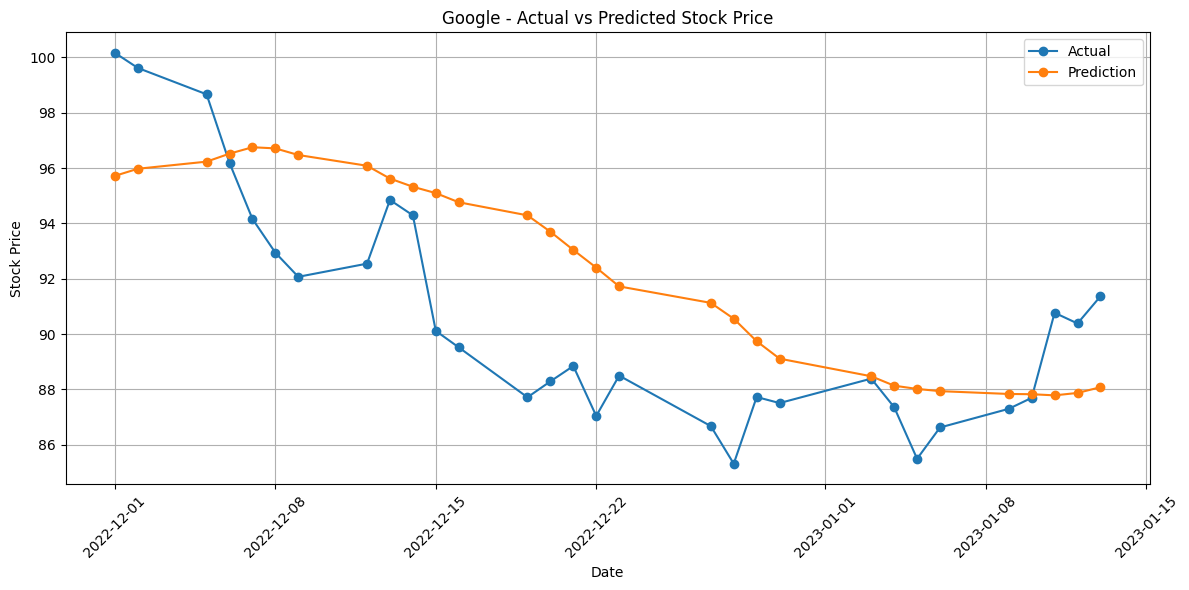

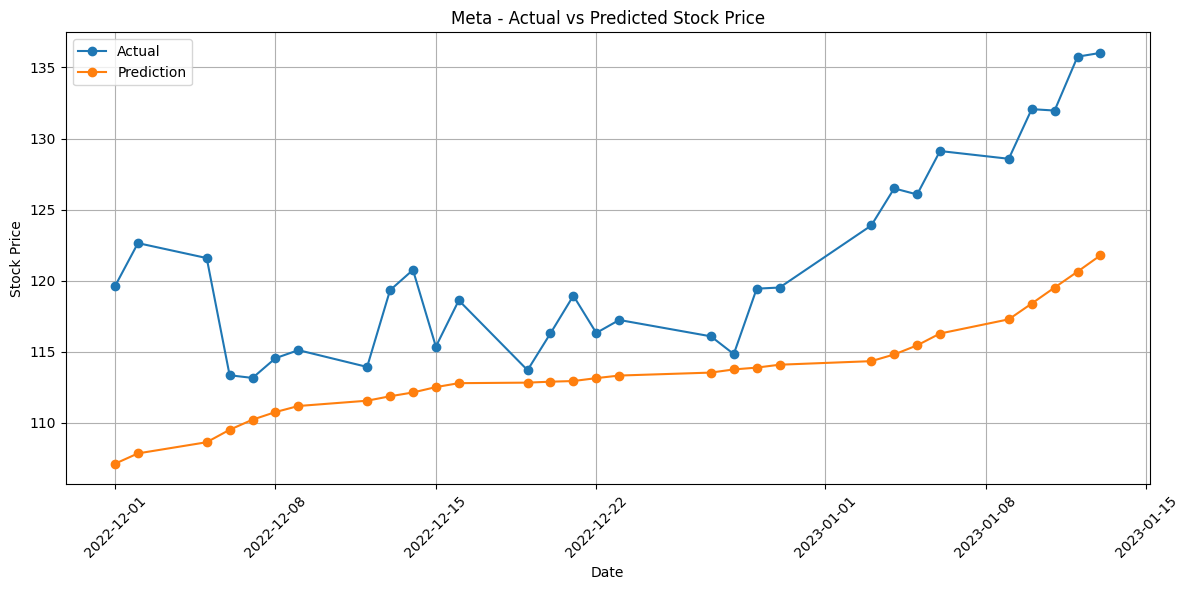

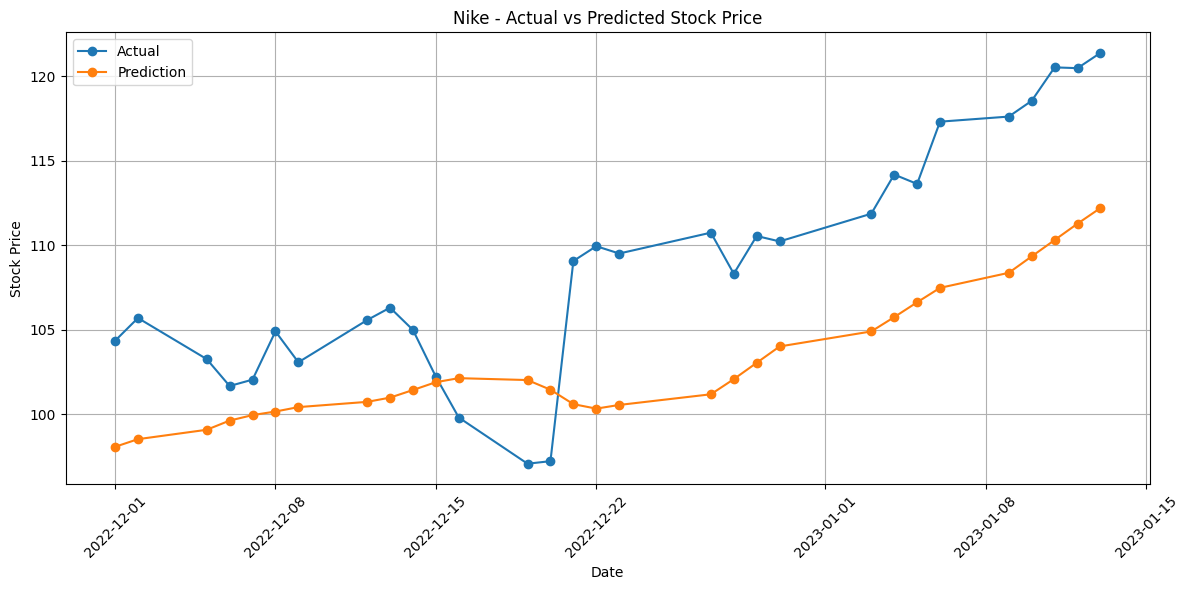

In [ ]:
import matplotlib.pyplot as plt

for company_name in plot_data:
    dates, actual, predicted = plot_data[company_name]

    plt.figure(figsize=(12,6))

    # Line chart with markers
    plt.plot(dates, actual, label="Actual",  marker='o')
    plt.plot(dates, predicted, label="Prediction", marker='o')

    plt.title(f"{company_name} - Actual vs Predicted Stock Price")
    plt.xlabel("Date")
    plt.ylabel("Stock Price")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
def create_sequences_multivariate(data, seq_length):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i])
        y.append(data[i, 3])  # Close price index
    return np.array(X), np.array(y)

In [ ]:
bilstm_results = []
bilstm_plot_data = {}

company_dfs = {
    "Amazon": df_amazon,
    "Apple": df_apple,
    "Google": df_google,
    "Meta": df_meta,
    "Nike": df_nike
}

for company_name, df in company_dfs.items():

    print(f"Processing (BiLSTM) {company_name}...")

    df = df.copy()
    df.set_index("Date", inplace=True)

    # Use stock + sentiment
    df = df[['Open', 'High', 'Low', 'Close', 'Volume', 'sentiment']]
    df.dropna(inplace=True)

    scaler = MinMaxScaler(feature_range=(0,1))
    scaled_data = scaler.fit_transform(df)

    seq_length = 30
    X, y = create_sequences_multivariate(scaled_data, seq_length)

    split_date = "2022-12-01"
    split_index = df.index.get_loc(split_date)
    split_index = split_index - seq_length

    X_train = X[:split_index]
    y_train = y[:split_index]

    X_test = X[split_index:]
    y_test = y[split_index:]

    test_dates = df.index[seq_length + split_index:]

    # BiLSTM Model
    model = Sequential([
        Input(shape=(X_train.shape[1], X_train.shape[2])),  # (30, 6)

        Bidirectional(LSTM(64, return_sequences=True)),
        Dropout(0.3),

        Bidirectional(LSTM(32)),
        Dropout(0.3),

        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')

    # Train WITHOUT EarlyStopping
    model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=32,
        verbose=0
    )

    predictions = model.predict(X_test, verbose=0)

    # Inverse transform
    last_sequences = X_test[:, -1, :]

    predictions_full = np.zeros((len(predictions), scaled_data.shape[1]))
    predictions_full[:, :] = last_sequences
    predictions_full[:, 3] = predictions.flatten()  # Close index

    predictions_actual = scaler.inverse_transform(predictions_full)
    predictions_close = predictions_actual[:, 3].reshape(-1, 1)

    # Actual values
    y_test_full = np.zeros((len(y_test), scaled_data.shape[1]))
    y_test_full[:, :] = last_sequences
    y_test_full[:, 3] = y_test.flatten()

    y_test_actual_full = scaler.inverse_transform(y_test_full)
    y_test_actual = y_test_actual_full[:, 3].reshape(-1, 1)

    rmse = np.sqrt(mean_squared_error(y_test_actual, predictions_close))
    mae = mean_absolute_error(y_test_actual, predictions_close)

    bilstm_results.append({
        "Company": company_name,
        "RMSE": round(rmse, 2),
        "MAE": round(mae, 2)
    })

    bilstm_plot_data[company_name] = (test_dates, y_test_actual, predictions_close)


Processing (BiLSTM) Amazon...


Processing (BiLSTM) Apple...
Processing (BiLSTM) Google...
Processing (BiLSTM) Meta...
Processing (BiLSTM) Nike...


In [ ]:

bilstm_results_df = pd.DataFrame(bilstm_results)
print(bilstm_results_df)

  Company  RMSE   MAE
0  Amazon  5.36  4.87
1   Apple  5.56  4.55
2  Google  2.79  2.39
3    Meta  7.36  6.37
4    Nike  6.50  5.98


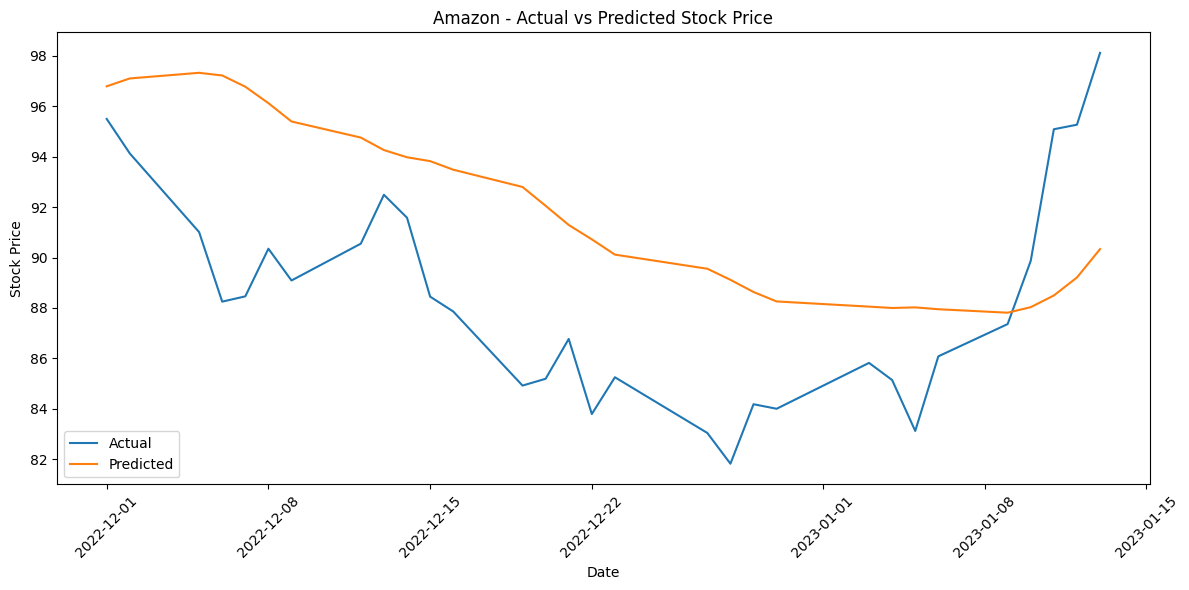

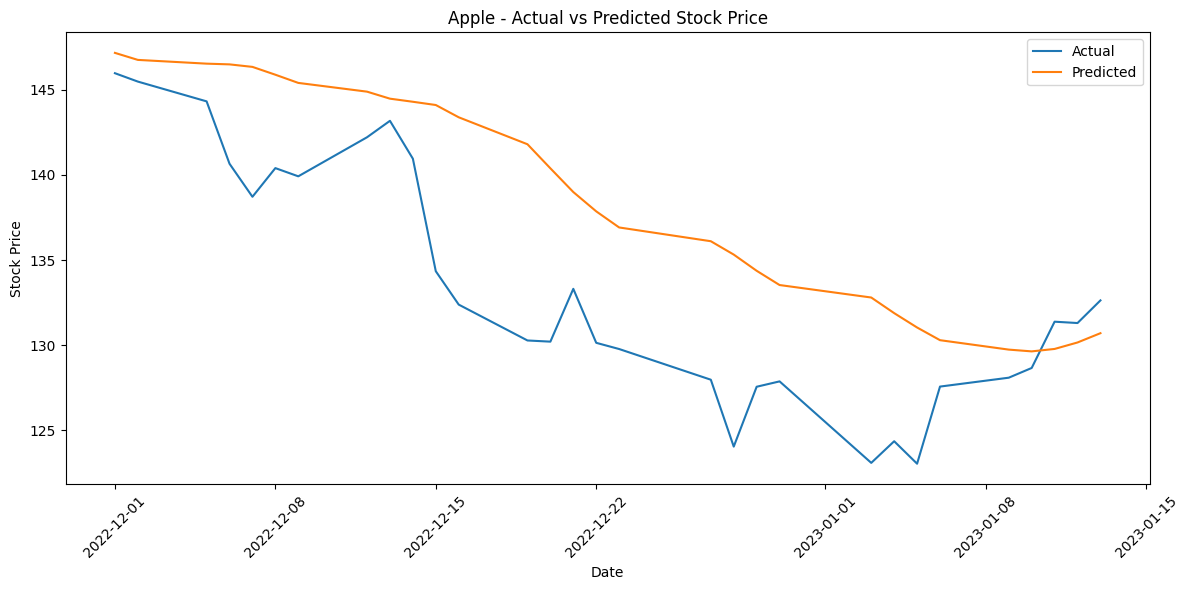

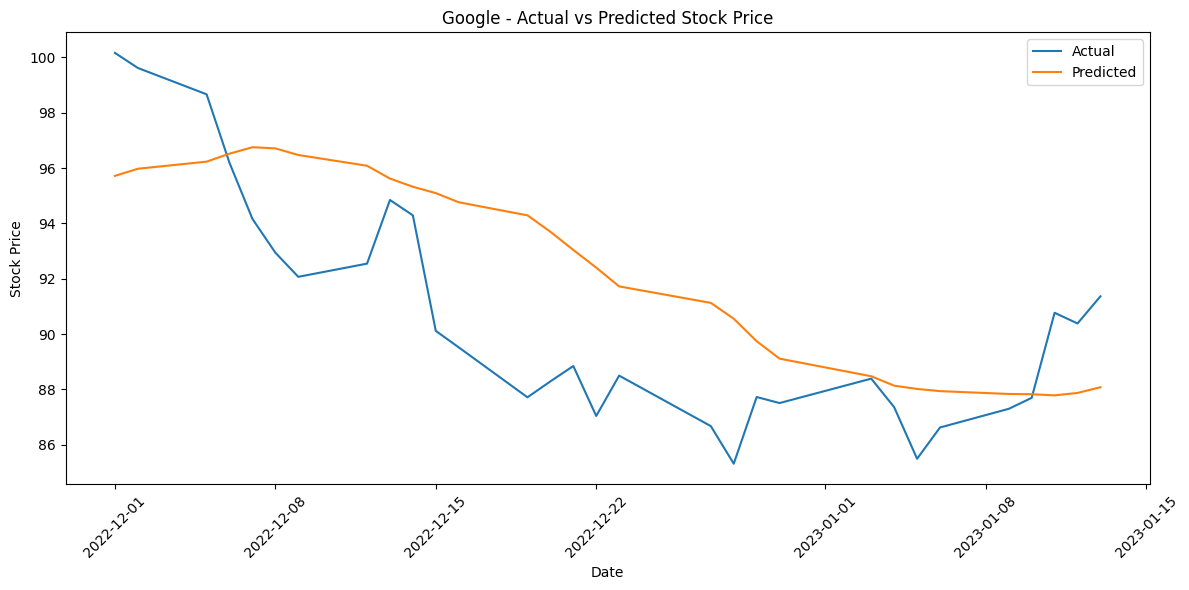

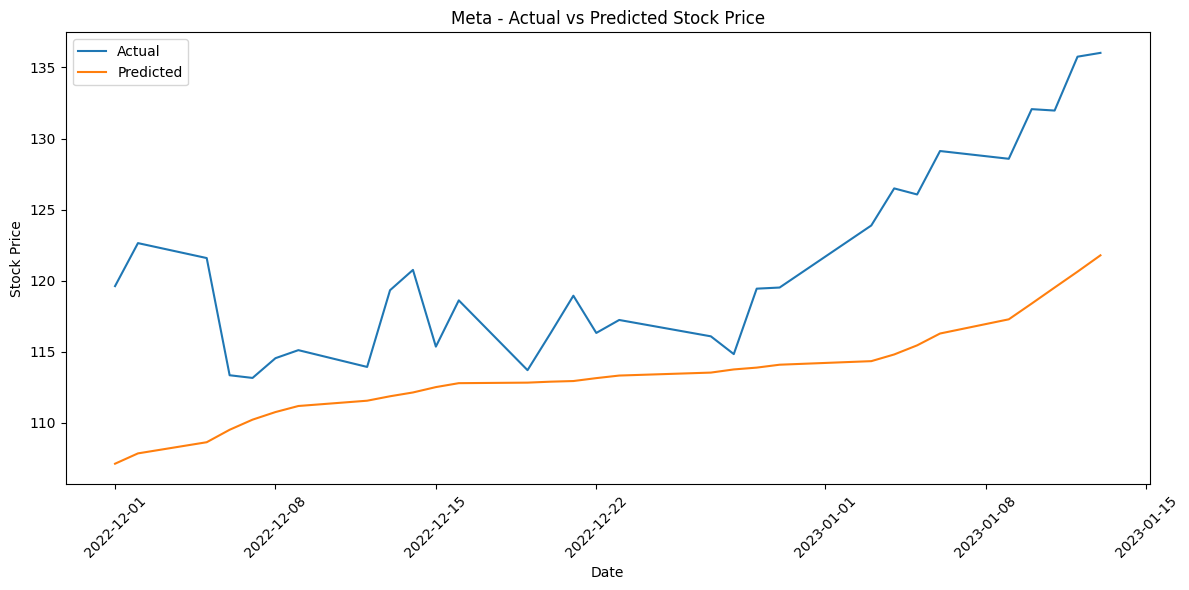

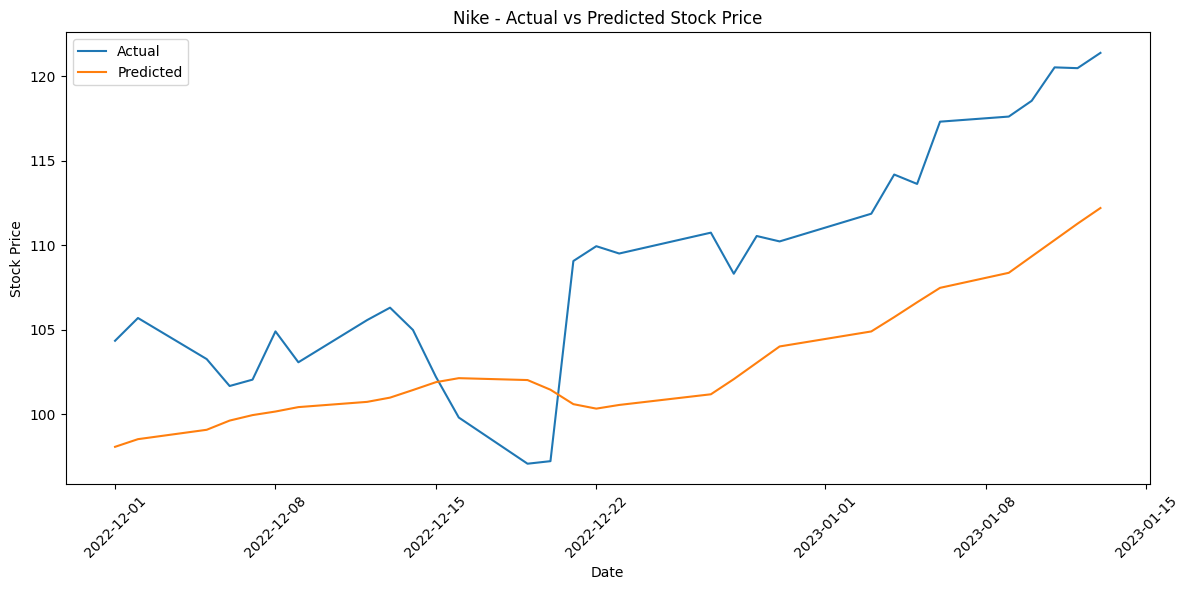

In [ ]:

for company_name in bilstm_plot_data:

    dates, actual, predicted = plot_data[company_name]

    plt.figure(figsize=(12,6))
    plt.plot(dates, actual, label="Actual")
    plt.plot(dates, predicted, label="Predicted")

    plt.title(f"{company_name} - Actual vs Predicted Stock Price")
    plt.xlabel("Date")
    plt.ylabel("Stock Price")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

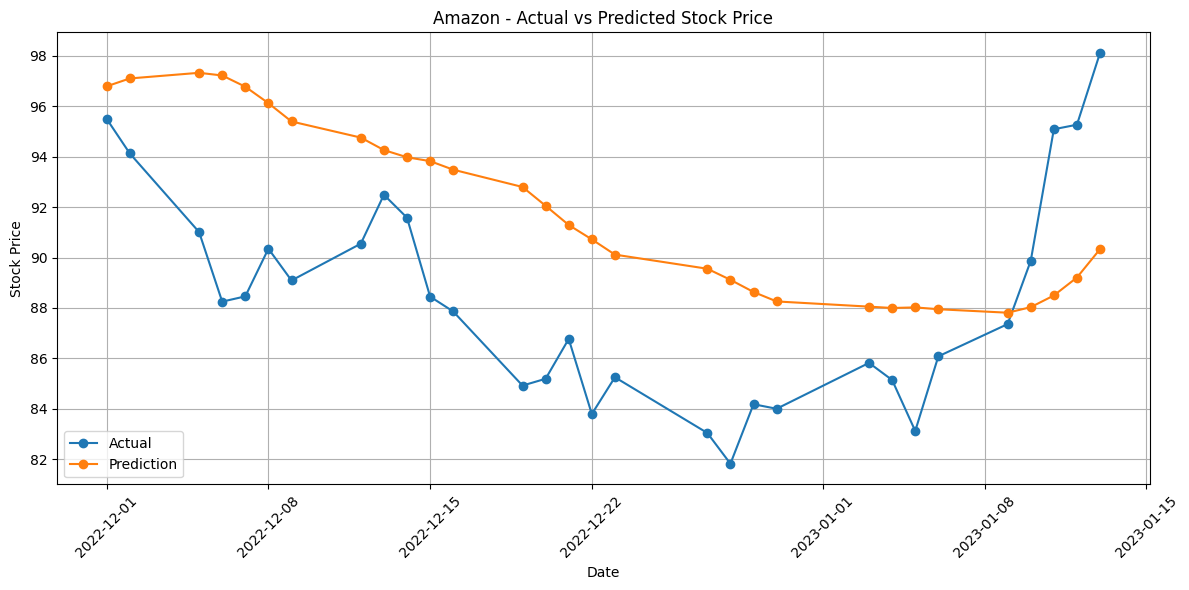

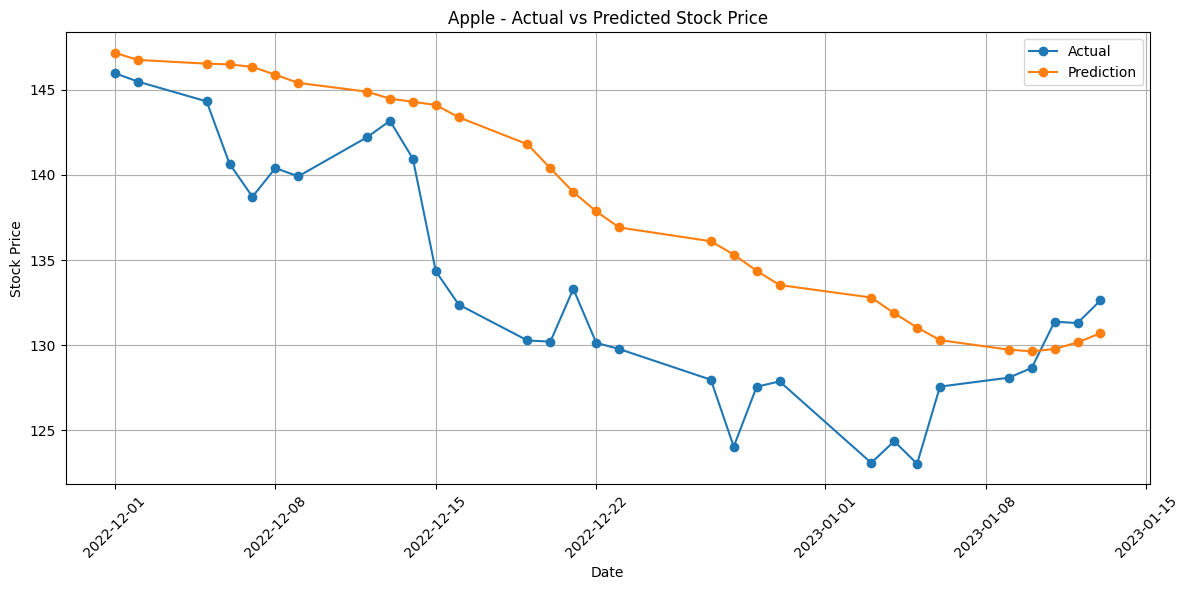

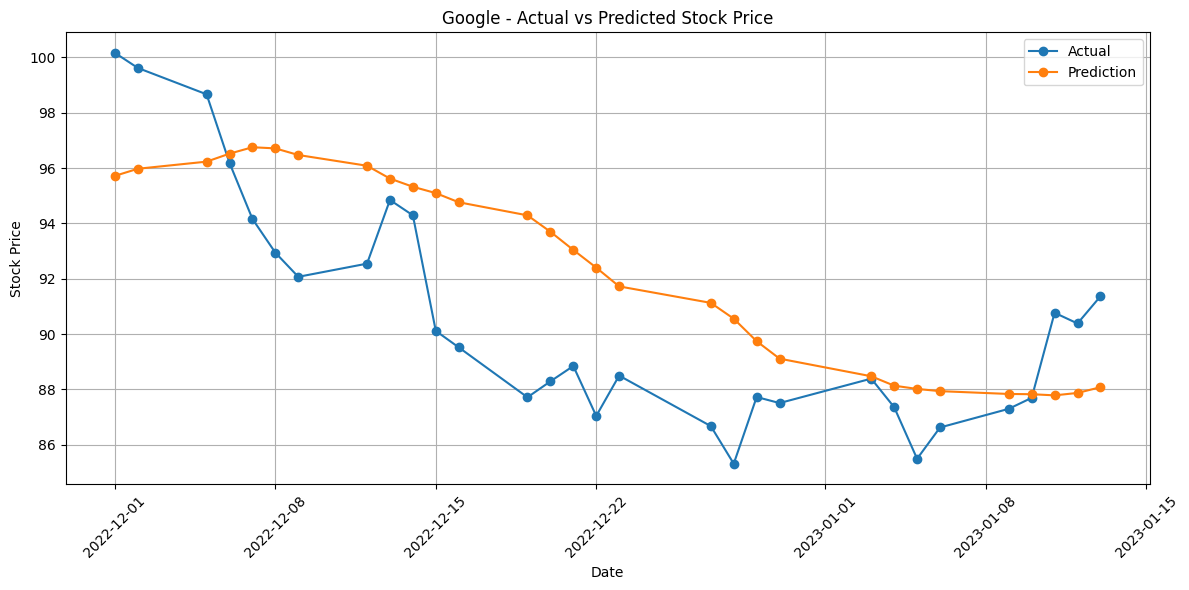

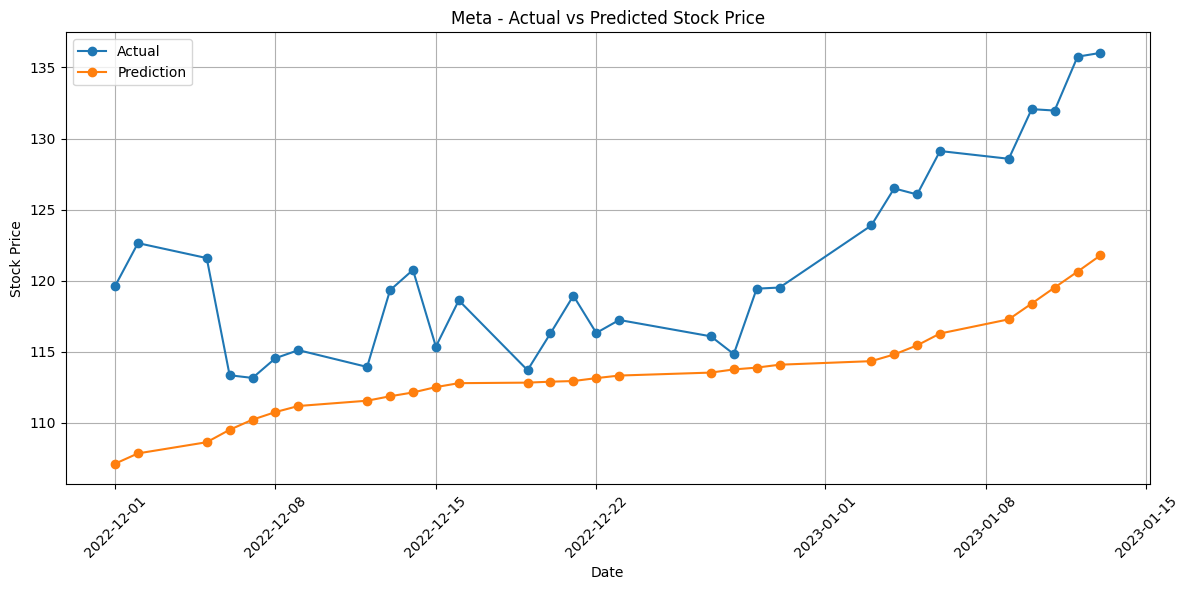

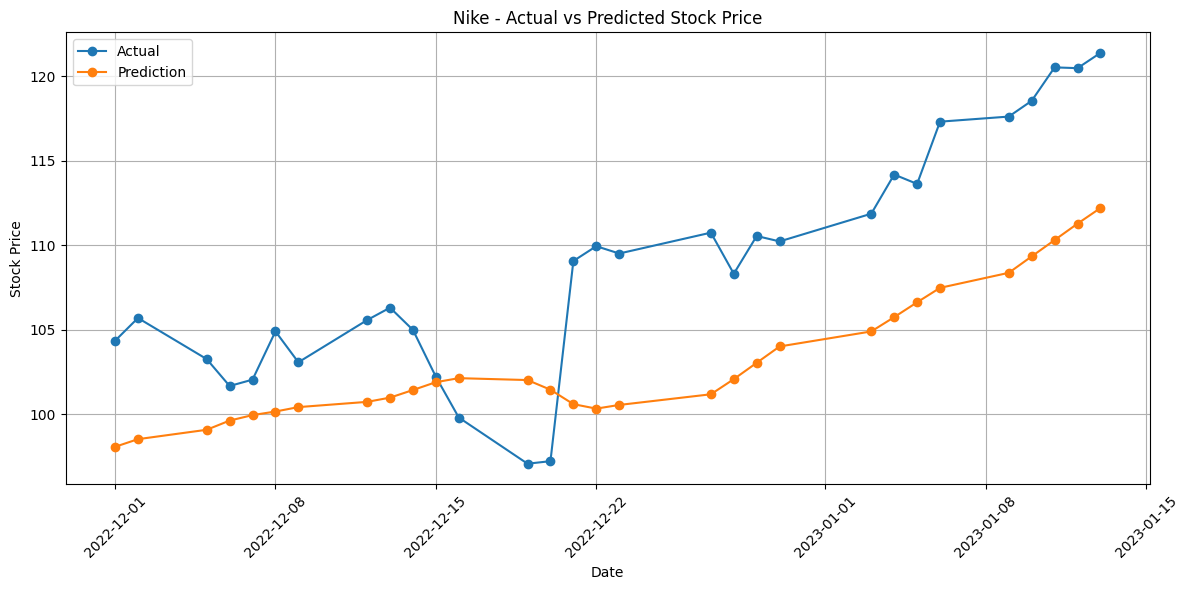

In [ ]:
import matplotlib.pyplot as plt

for company_name in bilstm_plot_data:
    dates, actual, predicted = plot_data[company_name]

    plt.figure(figsize=(12,6))

    # Line chart with markers
    plt.plot(dates, actual, label="Actual",  marker='o')
    plt.plot(dates, predicted, label="Prediction", marker='o')

    plt.title(f"{company_name} - Actual vs Predicted Stock Price")
    plt.xlabel("Date")
    plt.ylabel("Stock Price")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

ridge_results = []
ridge_plot_data = {}

company_dfs = {
    "Amazon": df_amazon,
    "Apple": df_apple,
    "Google": df_google,
    "Meta": df_meta,
    "Nike": df_nike
}

for company_name, df in company_dfs.items():

    print(f"Processing (Ridge) {company_name}...")

    df = df.copy()
    df.set_index("Date", inplace=True)

    # Create extra feature
    df['Price_Movement'] = df['Close'] - df['Open']

    df.dropna(inplace=True)

    # Define split date
    split_date = "2022-12-01"
    split_index = df.index.get_loc(split_date)

    # 🔥 Features (include sentiment)
    X = df[['Open', 'High', 'Low', 'Volume', 'sentiment', 'Price_Movement']]
    y = df['Close']

    # Time-based split
    X_train = X.iloc[:split_index]
    X_test = X.iloc[split_index:]
    y_train = y.iloc[:split_index]
    y_test = y.iloc[split_index:]

    test_dates = df.index[split_index:]

    # Scaling
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)

    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
    y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

    # Train Ridge
    ridge = Ridge(alpha=1.0)
    ridge.fit(X_train_scaled, y_train_scaled)

    # Predict
    pred_scaled = ridge.predict(X_test_scaled)
    predictions = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()
    y_test_actual = y_test.values

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
    mae = mean_absolute_error(y_test_actual, predictions)

    ridge_results.append({
        "Company": company_name,
        "RMSE": round(rmse, 2),
        "MAE": round(mae, 2)
    })

    ridge_plot_data[company_name] = (test_dates, y_test_actual, predictions)



Processing (Ridge) Amazon...
Processing (Ridge) Apple...
Processing (Ridge) Google...
Processing (Ridge) Meta...
Processing (Ridge) Nike...


In [ ]:
ridge_results_df = pd.DataFrame(ridge_results)
ridge_results_df

,Company,RMSE,MAE
0,Amazon,0.89,0.83
1,Apple,0.71,0.57
2,Google,0.69,0.64
3,Meta,1.84,1.77
4,Nike,0.32,0.26


In [ ]:
# Cell: Artificial Neural Network (ANN) for Stock Price Prediction
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

ann_results = []
ann_plot_data = {}

# Dictionary of your existing dataframes
companies_data = {
    'Apple': df_apple,
    'Amazon': df_amazon,
    'Nike': df_nike,
    'Google': df_google,
    'Meta': df_meta
}

for company_name, df in companies_data.items():

    print(f"Processing (ANN) {company_name}...")

    # Make sure Date is index
    if 'Date' in df.columns:
        df = df.set_index('Date')

    # Select required columns (already have sentiment)
    df_model = df[['Open', 'High', 'Low', 'Close', 'Volume', 'sentiment']].copy()
    df_model.dropna(inplace=True)

    # Create price movement feature
    df_model['Price_Movement'] = df_model['Close'] - df_model['Open']

    # Define split date
    split_date = "2022-12-01"
    split_index = df_model.index.get_loc(split_date)

    # Features & target
    X = df_model[['Open', 'High', 'Low', 'Volume', 'sentiment', 'Price_Movement']]
    y = df_model['Close']

    # Time-series split
    X_train = X.iloc[:split_index]
    X_test = X.iloc[split_index:]
    y_train = y.iloc[:split_index]
    y_test = y.iloc[split_index:]

    test_dates = df_model.index[split_index:]

    # Scale features and target
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)

    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

    # Build ANN
    model = Sequential([
        Input(shape=(X_train_scaled.shape[1],)),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    # EarlyStopping
    early_stop = EarlyStopping(
        monitor='loss',
        patience=10,
        verbose=0,
        restore_best_weights=True
    )

    # Train ANN
    model.fit(
        X_train_scaled, y_train_scaled,
        epochs=500,
        batch_size=16,
        verbose=0,
        callbacks=[early_stop]
    )

    # Predict
    pred_scaled = model.predict(X_test_scaled, verbose=0)
    predictions = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()
    y_test_actual = y_test.values

    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
    mae = mean_absolute_error(y_test_actual, predictions)

    # Store results
    ann_results.append({
        "Company": company_name,
        "RMSE": round(rmse, 2),
        "MAE": round(mae, 2)
    })

    # Store plot data
    ann_plot_data[company_name] = (test_dates, y_test_actual, predictions)

# Convert to DataFrame
ann_results_df = pd.DataFrame(ann_results)
print("\n📊 ANN Results:")
ann_results_df

Processing (ANN) Apple...
Processing (ANN) Amazon...
Processing (ANN) Nike...
Processing (ANN) Google...
Processing (ANN) Meta...

📊 ANN Results:


,Company,RMSE,MAE
0,Apple,4.03,3.37
1,Amazon,5.13,4.45
2,Nike,4.61,4.45
3,Google,2.40,1.46
4,Meta,6.88,6.16


In [ ]:
# Cell: Random Forest (RF) for Stock Price Prediction
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

rf_results = []
rf_plot_data = {}

# Dictionary of your existing dataframes
companies_data = {
    'Apple': df_apple,
    'Amazon': df_amazon,
    'Nike': df_nike,
    'Google': df_google,
    'Meta': df_meta
}

for company_name, df in companies_data.items():

    print(f"Processing (RF) {company_name}...")

    # Make sure Date is index
    if 'Date' in df.columns:
        df = df.set_index('Date')

    # Select required columns (including sentiment)
    df_model = df[['Open', 'High', 'Low', 'Close', 'Volume', 'sentiment']].copy()
    df_model.dropna(inplace=True)

    # Create price movement feature
    df_model['Price_Movement'] = df_model['Close'] - df_model['Open']

    # Define split date
    split_date = "2022-12-01"
    split_index = df_model.index.get_loc(split_date)

    # Features & Target (NOW INCLUDING SENTIMENT!)
    X = df_model[['Open', 'High', 'Low', 'Volume', 'sentiment', 'Price_Movement']]
    y = df_model['Close']

    # Time-series split
    X_train = X.iloc[:split_index]
    X_test = X.iloc[split_index:]
    y_train = y.iloc[:split_index]
    y_test = y.iloc[split_index:]

    test_dates = df_model.index[split_index:]

    # Scale features & target
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)

    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

    # Train Random Forest
    rf = RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train_scaled, y_train_scaled)

    # Make predictions
    pred_scaled = rf.predict(X_test_scaled)
    predictions = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()
    y_test_actual = y_test.values

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
    mae = mean_absolute_error(y_test_actual, predictions)

    # Store results
    rf_results.append({
        "Company": company_name,
        "RMSE": round(rmse, 2),
        "MAE": round(mae, 2)
    })

    # Store plot data
    rf_plot_data[company_name] = (test_dates, y_test_actual, predictions)

    # Optional: Feature importance
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': rf.feature_importances_
    }).sort_values('importance', ascending=False)
    print(f"\n{company_name} - Top features:")
    print(feature_importance.head(3))

# Convert results to DataFrame
rf_results_df = pd.DataFrame(rf_results)
print("\n📊 Random Forest Results:")
rf_results_df

Processing (RF) Apple...

Apple - Top features:
  feature  importance
1    High    0.647701
2     Low    0.334138
0    Open    0.009853
Processing (RF) Amazon...

Amazon - Top features:
  feature  importance
2     Low    0.744869
1    High    0.208063
0    Open    0.044220
Processing (RF) Nike...

Nike - Top features:
  feature  importance
2     Low    0.607474
1    High    0.339088
0    Open    0.051507
Processing (RF) Google...

Google - Top features:
  feature  importance
1    High    0.542866
2     Low    0.398571
0    Open    0.055904
Processing (RF) Meta...

Meta - Top features:
  feature  importance
2     Low    0.424974
1    High    0.315422
0    Open    0.258263

📊 Random Forest Results:


,Company,RMSE,MAE
0,Apple,2.50,1.71
1,Amazon,3.74,2.95
2,Nike,0.81,0.61
3,Google,1.16,0.95
4,Meta,2.58,2.06


In [ ]:
# Cell: XGBoost (XGBRegressor) for Stock Price Prediction
from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

xgb_results = []
xgb_plot_data = []

# Dictionary of your existing dataframes
companies_data = {
    'Apple': df_apple,
    'Amazon': df_amazon,
    'Nike': df_nike,
    'Google': df_google,
    'Meta': df_meta
}

for company_name, df in companies_data.items():

    print(f"Processing (XGBoost) {company_name}...")

    # Make sure Date is index
    if 'Date' in df.columns:
        df = df.set_index('Date')

    # Select required columns (with sentiment)
    df_model = df[['Open', 'High', 'Low', 'Close', 'Volume', 'sentiment']].copy()
    df_model.dropna(inplace=True)

    # Create price movement feature
    df_model['Price_Movement'] = df_model['Close'] - df_model['Open']

    # Define split date
    split_date = "2022-12-01"
    split_index = df_model.index.get_loc(split_date)

    # Features & Target (INCLUDING SENTIMENT!)
    X = df_model[['Open', 'High', 'Low', 'Volume', 'sentiment', 'Price_Movement']]
    y = df_model['Close']

    # Time-series split
    X_train = X.iloc[:split_index]
    X_test = X.iloc[split_index:]
    y_train = y.iloc[:split_index]
    y_test = y.iloc[split_index:]

    test_dates = df_model.index[split_index:]

    # Scale features & target
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)

    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

    # Train XGBoost model
    xgb = XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
    xgb.fit(X_train_scaled, y_train_scaled)

    # Make predictions
    pred_scaled = xgb.predict(X_test_scaled)
    predictions = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()
    y_test_actual = y_test.values

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
    mae = mean_absolute_error(y_test_actual, predictions)

    # Store results
    xgb_results.append({
        "Company": company_name,
        "RMSE": round(rmse, 2),
        "MAE": round(mae, 2)
    })

    # Store plot data
    xgb_plot_data.append({
        'company': company_name,
        'dates': test_dates,
        'actual': y_test_actual,
        'predicted': predictions
    })

    # Optional: Feature importance
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': xgb.feature_importances_
    }).sort_values('importance', ascending=False)
    print(f"\n{company_name} - Top features:")
    print(feature_importance.head(3))

# Convert results to DataFrame
xgb_results_df = pd.DataFrame(xgb_results)
print("\n📊 XGBoost Results:")
xgb_results_df

Processing (XGBoost) Apple...

Apple - Top features:
  feature  importance
2     Low    0.578739
1    High    0.403948
0    Open    0.008115
Processing (XGBoost) Amazon...

Amazon - Top features:
  feature  importance
2     Low    0.697396
1    High    0.268442
0    Open    0.031987
Processing (XGBoost) Nike...

Nike - Top features:
  feature  importance
2     Low    0.614952
1    High    0.363339
0    Open    0.019466
Processing (XGBoost) Google...

Google - Top features:
  feature  importance
1    High    0.511364
2     Low    0.470510
0    Open    0.015034
Processing (XGBoost) Meta...

Meta - Top features:
  feature  importance
1    High    0.349499
2     Low    0.335386
0    Open    0.314048

📊 XGBoost Results:


,Company,RMSE,MAE
0,Apple,1.85,1.36
1,Amazon,2.56,1.98
2,Nike,0.67,0.51
3,Google,1.03,0.78
4,Meta,2.58,2.01
